In [28]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import  ncx2, kstest
import pandas as pd
from numba import  njit
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gamma


# Примеры

In [2]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx # Number of trajectories
        self.Nt = Nt # Number of discretization steps
        self.init_state = init_state

    #Wiener Process by default
    #use @staticmethod for numba compatibility with @njit
    @staticmethod
    @njit
    def bxt(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return 1

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return 0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def EulerSolution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1], t_data[i - 1], self.params) * dt +\
                        self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1]
        return t_data, x_data

    def Milstein2Solution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + (self.bxt(x_data[i - 1], t_data[i - 1], self.params) - 1/2 * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt_x(x_data[i - 1], t_data[i - 1], self.params)) * dt +\
                        self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1] + 1/2 * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt_x(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1]**2 +\
                        (1/2 * self.bxt(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt_x(x_data[i - 1], t_data[i - 1], self.params) + 1/2 * self.bxt_x(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) +\
                        1/4 * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params)**2 * self.sigmaxt_xx(x_data[i - 1], t_data[i - 1], self.params)) * dt * dwt[i - 1] +\
                        (1/2 * self.bxt(x_data[i - 1], t_data[i - 1], self.params) * self.bxt_x(x_data[i - 1], t_data[i - 1], self.params) + 1/4 * self.bxt_xx(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params)**2) * dt**2
        return t_data, x_data


class CIRprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2, theta3]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] - params[1] * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * np.sqrt(np.maximum(x,0))

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[1]

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[2] * 1/2 * 1/np.sqrt(np.maximum(x,0))

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return -params[2] * 1/4 * 1/np.maximum(x,0)**(3/2)

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

    def ExactSolution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        Ito_integral_sum = np.zeros(self.Nx)
        for i in range(1, self.Nt + 1):
            Determinated_part = (x_data[0] - theta1 / theta2) * np.exp(-theta2 * t_data[i]) + theta1/theta2
            #avoiding exp overflow
            Ito_integral_sum = (Ito_integral_sum + theta3 * np.sqrt(np.maximum(x_data[i - 1], 0)) * dwt[i - 1]) * np.exp(-theta2 * dt)
            x_data[i] = Determinated_part + Ito_integral_sum
        return t_data, x_data

    def StationaryState(self):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        c = 2 * k / (sigma**2)
        u = 0
        q = 2 * k * theta / sigma**2 - 1

        return ncx2.rvs(2 * q + 2, 2 * u, size = self.Nx) / (2 * c)

    def ProcessDistribution(self, x, t, x0, t0):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        c = 2 * k / (sigma**2 * (1 - np.exp(-k * (t - t0))))
        u = c * x0 * np.exp(-k * (t - t0))
        #v = c * x
        q = 2 * k * theta / sigma**2 - 1
        return ncx2.pdf(2 * c * x, 2 * q + 2, 2 * u) * (2 * c) #2c is normalazing constant

    def StationaryDistribution(self, x):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        c = 2 * k / (sigma**2)
        u = 0
        q = 2 * k * theta / sigma**2 - 1
        return ncx2.pdf(2 * c * x, 2 * q + 2, 2 * u) * (2 * c)

Execise 1. Simulate a Cox-Ingersoll-Ross (CIR) model
$$
dX_t = (\theta_1 - \theta_2 X_t)dt + \theta_3 \sqrt{X_t}dW_t
$$
with $\theta = (6, 2, 1)$, and choose the bandwidth according to Scott’s rule and implement the non-parametric kernel estimation for stationary density of the CIR model.

Plot in a graph the true stationary density against the estimated one for
*   $n=1000$, $\Delta_n=1$,
*   $n=15000$, $\Delta_n=0.01$.



In [3]:
def StationaryDistributionKernelEstimator(x, x_data, delta = None):
    n = len(x_data)
    m = 1

    hn = 1

    if delta is None:
        hn = np.std(x_data) * n**(-1 / (m + 4))
    else:
        hn = delta

    pi = np.zeros(len(x))

    for j in range(0, len(x)):
        K = 1/np.sqrt(2 * np.pi) * np.exp(-1/2 * (x[j] - x_data)**2 / hn**2)

        pi[j] = 1 / (n * hn) * np.sum(K)

    return pi

In [4]:
'''Расчёт на 1 траектрии
Для обеспечения стационарности задаём T очень большим. T/Nt = delta t - шаг дискретизации по времени
'''

Nx = 1
Nt = 100000
T = 1000

params_CIR = [6, 2, 1]

CIRp = CIRprocess(params_CIR, T, Nx, Nt)
CIRp.init_state = CIRp.StationaryState()
t_data, x_data_CIR = CIRp.ExactSolution()

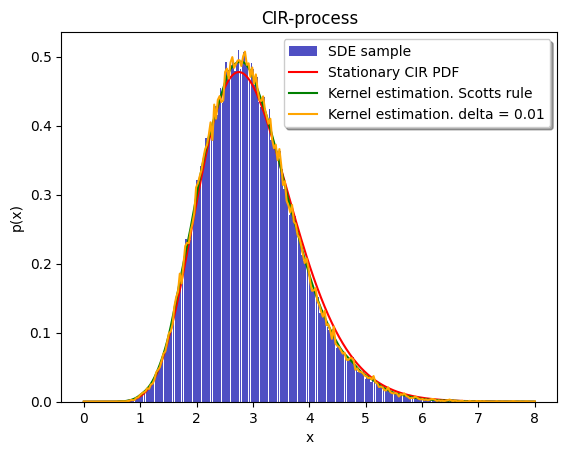

In [5]:
n = np.random.randint(0, Nt)
fig, ax = plt.subplots()
x_data = np.linspace(0, 8, 250)

i = np.random.randint(0, Nt)

n, bins, patches = ax.hist(x_data_CIR.flatten(), bins=x_data, density=True, color='#0504aa', alpha=0.7, rwidth=0.85, label = 'SDE sample')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title(f'CIR-process', loc = 'center')

ax.plot(x_data, CIRp.StationaryDistribution(x_data), label = 'Stationary CIR PDF', color = 'red')
#ax.plot(x_data, CIRp.ProcessDistribution(x_data, T * i / Nt, x0, 0), label = 'Stationary CIR PDF', color = 'red')

ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR.flatten()), label = f'Kernel estimation. Scotts rule', color = 'green')

d = 0.01
ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR.flatten(), delta = d),
        label = f'Kernel estimation. delta = {d}', color = 'orange')

ax.legend(loc = 'upper right', fancybox = True, shadow = True)
plt.show()

In [6]:
'''Расчёт на Nx траектриях
Для обеспечения стационарности задаём число траекторий Nx большим, а так же
в качестве начального состояния задаём стационарное состояние
'''
Nx = 15000
Nt = 300

T = 1

params_CIR = [6, 2, 1]

CIRp = CIRprocess(params_CIR, T, Nx, Nt)
CIRp.init_state = CIRp.StationaryState()
t_data, x_data_CIR = CIRp.ExactSolution()

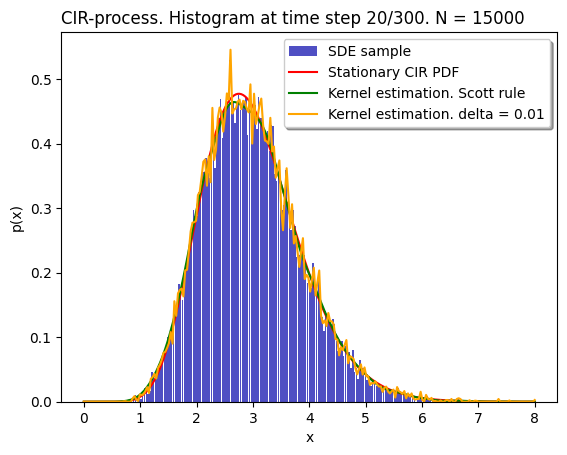

In [7]:
n = np.random.randint(0, Nt)
fig, ax = plt.subplots()
x_data = np.linspace(0, 8, 250)

i = np.random.randint(0, Nt)

n, bins, patches = ax.hist(x_data_CIR[i], bins=x_data, density=True, color='#0504aa', alpha=0.7, rwidth=0.85, label = 'SDE sample')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title(f'CIR-process. Histogram at time step {i}/{Nt}. N = {Nx}', loc = 'left')

ax.plot(x_data, CIRp.StationaryDistribution(x_data), label = 'Stationary CIR PDF', color = 'red')
#ax.plot(x_data, CIRp.ProcessDistribution(x_data, T * i / Nt, x0, 0), label = 'Stationary CIR PDF', color = 'red')

ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR[i]), label = f'Kernel estimation. Scott rule', color = 'green')

d = 0.01
ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR[i], delta = d),
        label = f'Kernel estimation. delta = {d}', color = 'orange')

ax.legend(loc = 'upper right', fancybox = True, shadow = True)
plt.show()

Task. Estimate the quality of the obtained approximations with statistical criteria and provide conclusions.

In [8]:
# your code

Task. Study the effect of the bandwidth $h_n$ and the mesh $∆_n$ on the kernel estimator and plot a 3D graph.

In [9]:
# your code

Task 2. Implement a non-parametric drift estimator

$$
\hat{b}_n(x) = \frac{\sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)(X_{i+1}-X_i)} {\Delta_n \sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)}
$$

and diffusion estimator
$$
\hat{\sigma}^2_n(x) = \frac{\sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)(X_{i+1}-X_i)^2} {\Delta_n \sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)}.$$


for the model from previous item and plot two graphs.
Use the

*  Gaussian kernel $K(u) = \frac{1}{\sqrt{2\pi}} \exp \left(-\frac{1}{2}u^2\right)$,
*  Uniform kernel $K(u)=1/2$,
*  Epanechnikov (parabolic) kernel $K(u)=\frac{3}{4}(1-u^2)$.


In [10]:
from typing import Literal

def NormalKernel(z):
    return 1/np.sqrt(2 * np.pi) * np.exp(-1/2 * z**2)

def UniformKernel(z):
    return 1/2 * np.ones_like(z)

def ParabolicKernel(z):
    return 3/4 * (1 - z**2)

def DiffusionKernelEstimator(x, x_data, delta = None, method: Literal['normal', 'uniform', 'parabolic'] = 'normal'):
    n = len(x_data)
    m = 1

    hn = 1

    hn = np.std(x_data) * n**(-1 / (m + 4))

    s2 = np.zeros(len(x))

    for j in range(0, len(x)):
        K1 = 0
        K2 = 0
        z = (x[j] - x_data)**2 / hn**2
        if method == 'normal':
            K = NormalKernel(z)
        elif method == 'uniform':
            K = UniformKernel(z)
        elif method == 'parabolic':
            K = ParabolicKernel(z)
        else:
            raise ValueError(f"method = {method} not implemented")

        K1 = np.sum(K[0:n-1] * (x_data[1:] - x_data[0:n-1])**2)
        K2 = np.sum(K)
        if K2 == 0:
            s2[j] = 0
        else:
            s2[j] = K1 / K2

    if delta is None:
        delta = 1

    return s2 / delta

def DriftKernelEstimator(x, x_data, delta = None, method: Literal['normal', 'uniform', 'parabolic'] = 'normal'):
    n = len(x_data)
    m = 1

    hn = 1

    hn = np.std(x_data) * n**(-1 / (m + 4))

    s2 = np.zeros(len(x))

    for j in range(0, len(x)):
        K1 = 0
        K2 = 0
        z = (x[j] - x_data)**2 / hn**2
        if method == 'normal':
            K = NormalKernel(z)
        elif method == 'uniform':
            K = UniformKernel(z)
        elif method == 'parabolic':
            K = ParabolicKernel(z)
        else:
            raise ValueError(f"method = {method} not implemented")

        K1 = np.sum(K[0:n-1] * (x_data[1:] - x_data[0:n-1]))
        K2 = np.sum(K)
        if K2 == 0:
            s2[j] = 0
        else:
            s2[j] = K1 / K2

    if delta is None:
        delta = 1

    return s2 / delta

In [11]:
Nx = 1
Nt = 100000

T = 1000

x_data = np.linspace(0, 6, 200)

params_CIR = [6, 2, 1]

CIRp = CIRprocess(params_CIR, T, Nx, Nt)
t_data, x_data_CIR = CIRp.ExactSolution()

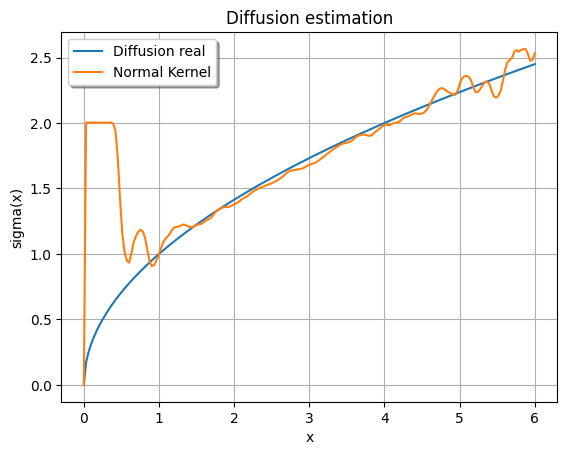

In [12]:
sigma_data = CIRp.sigmaxt(x_data, 0, CIRp.params)

plt.plot(x_data, sigma_data, label = 'Diffusion real')


diffke = DiffusionKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'normal')
plt.plot(x_data, np.sqrt(diffke), label = 'Normal Kernel')

#diffke = DiffusionKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'parabolic')
#plt.plot(x_data, np.sqrt(diffke), label = 'Parabolic Kernel')

#diffke = DiffusionKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'uniform')
#plt.plot(x_data, np.sqrt(diffke), label = 'Uniform Kernel')

plt.title("Diffusion estimation")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("x")
plt.ylabel("sigma(x)")
plt.grid(True)
plt.show()

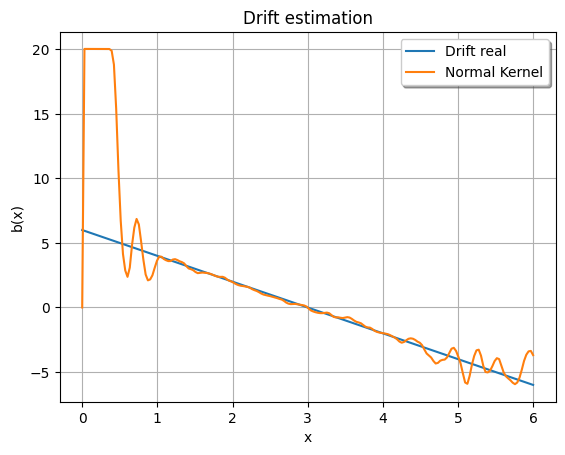

In [13]:
b_data = CIRp.bxt(x_data, 0, CIRp.params)

plt.plot(x_data, b_data, label = 'Drift real')


driftke = DriftKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'normal')
plt.plot(x_data, driftke, label = 'Normal Kernel')

#driftke = DriftKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'parabolic')
#plt.plot(x_data, driftke, label = 'Parabolic Kernel')

#driftke = DriftKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'uniform')
#plt.plot(x_data, driftke, label = 'Uniform Kernel')

plt.title("Drift estimation")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("x")
plt.ylabel("b(x)")
plt.grid(True)
plt.show()

# Задачи

Задача 1. Оценивание стационарной плотности ансамбля
1. Для модели CIR или OU сгенерируйте траекторию процесса с большим финальным временем $T$ для достижения стационарного режима.

2. Реализуйте функцию `StationaryDistributionKernelEstimator`.

3. Постройте на одном графике теоретическую стационарную плотность $π(x)$ и три ядерные оценки с использованием различных ядер: гауссовского, равномерного и Епанечникова (параболического). Укажите на графике (в легенде или заголовке) какая использована ширина окна (Scott's rule) для ядер.

4. Сделайте выводы.


Scott bandwidth = 0.11154096412854192


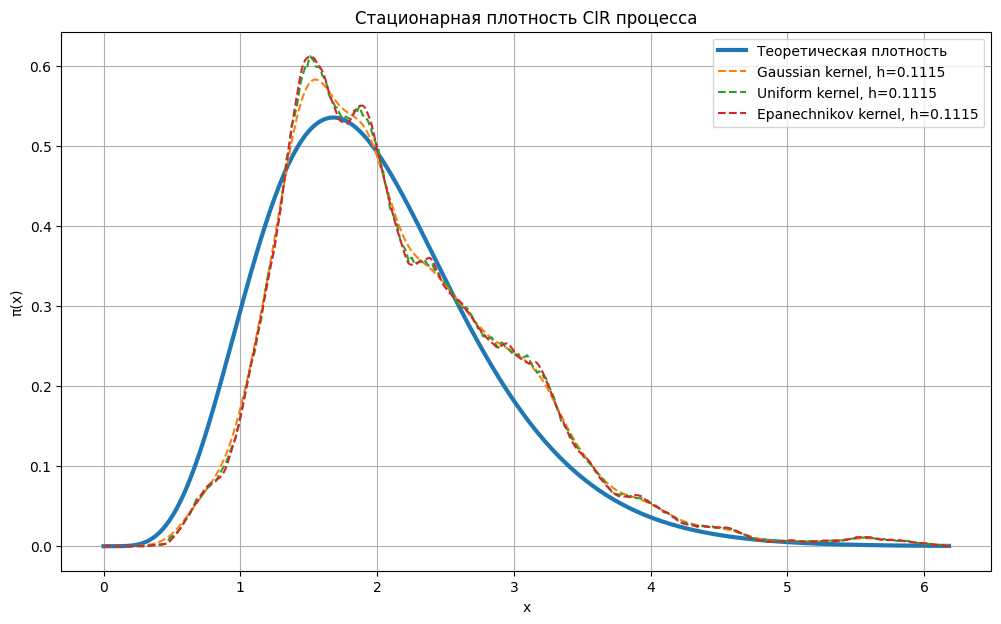

In [14]:
theta1 = 2.0
theta2 = 1.0
theta3 = 0.8

params = [theta1, theta2, theta3]

T = 200
Nt = 50000
Nx = 1

# генерация процесса
process = CIRprocess(params, T=T, Nt=Nt, Nx=Nx)
t_data, x_data = process.EulerSolution()
trajectory = x_data[:, 0]
trajectory_stationary = trajectory[int(0.5 * Nt):]

# сетка х
x = np.linspace(0, np.max(trajectory_stationary), 500)

pi_theory = process.StationaryDistribution(x)

# ширина окна
n = len(trajectory_stationary)
hn = np.std(trajectory_stationary) * n ** (-1 / 5)

print("Scott bandwidth =", hn)

pi_normal = StationaryDistributionKernelEstimator(
    x,
    trajectory_stationary,
    delta=hn)

# Равномерное ядро
def StationaryUniformEstimator(x, x_data, h):
    n = len(x_data)
    pi = np.zeros(len(x))

    for j in range(len(x)):
        z = (x[j] - x_data) / h
        K = 0.5 * (np.abs(z) <= 1)

        pi[j] = np.sum(K) / (n * h)

    return pi

# Параболическое ядро (Епанечникова)
def StationaryParabolicEstimator(x, x_data, h):
    n = len(x_data)
    pi = np.zeros(len(x))
    for j in range(len(x)):
        z = (x[j] - x_data) / h
        K = 0.75 * (1 - z**2) * (np.abs(z) <= 1)
        pi[j] = np.sum(K) / (n * h)
    return pi
pi_uniform = StationaryUniformEstimator(
    x,
    trajectory_stationary,
    hn)
pi_parabolic = StationaryParabolicEstimator(
    x,
    trajectory_stationary,
    hn)


plt.figure(figsize=(12, 7))

plt.plot(
    x,
    pi_theory,
    linewidth=3,
    label='Теоретическая плотность')

plt.plot(
    x,
    pi_normal,
    '--',
    label=f'Gaussian kernel, h={hn:.4f}')

plt.plot(
    x,
    pi_uniform,
    '--',
    label=f'Uniform kernel, h={hn:.4f}')

plt.plot(
    x,
    pi_parabolic,
    '--',
    label=f'Epanechnikov kernel, h={hn:.4f}')

plt.xlabel('x')
plt.ylabel('π(x)')
plt.title('Стационарная плотность CIR процесса')
plt.grid()
plt.legend()

plt.show()

Все три ядерные оценки близки показывают форму близкую к теоретической стационарной плотности. Гауссовское ядро даёт более гладкую оценку. Ядро Епанечникова даёт небольшое преимущество в точности.


При выбранной ширине окна (0.0968) все ядровые оценки являются состоятеьными и восстанавливают стационарное распределение процесса


Задача 2. Исследование правила Скотта для ширины окна

1. Вычислите оптимальную ширину окна $h_n$ по **правилу Скотта**, где $h_n \propto d \cdot n^{-1/5}$.

2. Постройте 3D-график зависимости ошибки аппроксимации (MSE) от ширины окна $h_n$ и шага дискретизации данных $\Delta_n$.

3. Проверьте утверждение, что при $n \to \infty$ и $h_n \to 0$ оценка сходится к истинной плотности.

4. Сделайте выводы.



In [15]:
def scott_bandwidth(x_data):
    n = len(x_data)
    d = np.std(x_data)
    return d * n ** (-1/5)

def mse(pi_true, pi_est, x):
    return np.mean((pi_true - pi_est)**2)

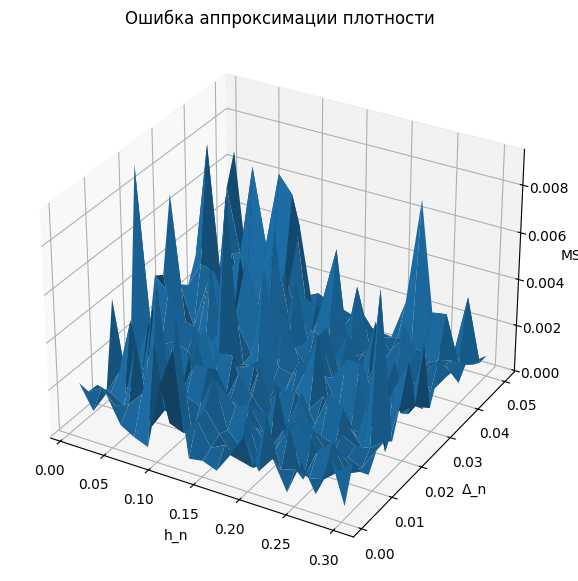

In [16]:
h_vals = np.linspace(0.01, 0.3, 20)
dt_vals = np.linspace(0.001, 0.05, 20)

H, D = np.meshgrid(h_vals, dt_vals)
MSE = np.zeros_like(H)

for i in range(len(dt_vals)):
    for j in range(len(h_vals)):

        dt = dt_vals[i]
        Nt_local = int(T / dt)

        process = CIRprocess(params, T=T, Nt=Nt_local, Nx=1)
        _, x_data = process.EulerSolution()

        sample = x_data[int(Nt_local/2):, 0]

        x_grid = np.linspace(0, np.max(sample), 200)

        pi_true = process.StationaryDistribution(x_grid)

        pi_est = StationaryDistributionKernelEstimator(
            x_grid,
            sample,
            delta=h_vals[j] )

        MSE[i, j] = mse(pi_true, pi_est, x_grid)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(H, D, MSE)

ax.set_xlabel("h_n")
ax.set_ylabel("Δ_n")
ax.set_zlabel("MSE")

plt.title("Ошибка аппроксимации плотности")
plt.show()

при малых Δn динамика процесса более точная, при больших численная ошибка увеличивается. При увеличении n и уменьшении h ядровая оценка сходится к истинной стационарной плотности процесса.

Правило Скотта даёт оптимальный выбор $h_n$, при его использовании и малом Δn оценка плотности является состоятельной

Задача 3. Непараметрическое "восстановление" коэффициентов СДУ


1. Используя оценки Флоренс-Змиру для сноса $\hat{b}_n(x)$ и диффузии $\hat{\sigma}^2_n(x)$ реализуйте функции `DriftKernelEstimator` и `DiffusionKernelEstimator`.

2. Постройте графики восстановленных коэффициентов в сравнении с истинными функциями $b(x)$ и $\sigma(x)$, заложенными в модели (модель и ее коэффициенты выбрать самостоятельно).

3. Оцените влияние «шумности» данных на краях области определения, где данных для усреднения недостаточно.

4. Проведите исследование влияния размера окна $h$ на оценки.

5. Сделайте выводы.


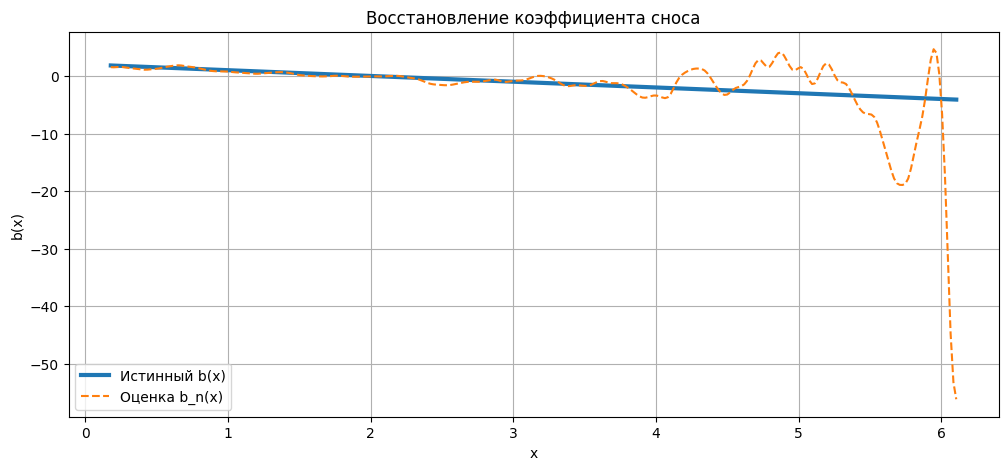

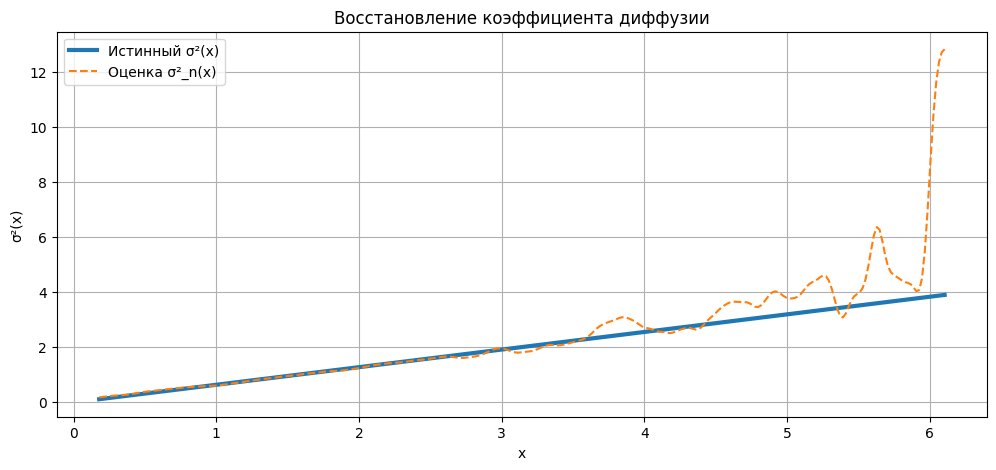

In [21]:
params = [2.0, 1.0, 0.8]

T = 200
Nt = 50000

process = CIRprocess(
    params,
    T=T,
    Nt=Nt,
    Nx=1)

t_data, x_data = process.EulerSolution()
trajectory = x_data[:, 0]

# стационарная часть
trajectory = trajectory[int(Nt/2):]

delta = T / Nt


x_grid = np.linspace(
    np.min(trajectory),
    np.max(trajectory),
    300)

theta1, theta2, theta3 = params
b_true = theta1 - theta2 * x_grid
sigma2_true = theta3**2 * x_grid


b_est = DriftKernelEstimator(
    x_grid,
    trajectory,
    delta=delta,
    method='normal')
sigma2_est = DiffusionKernelEstimator(
    x_grid,
    trajectory,
    delta=delta,
    method='normal')


plt.figure(figsize=(12,5))
plt.plot(
    x_grid,
    b_true,
    linewidth=3,
    label='Истинный b(x)')
plt.plot(
    x_grid,
    b_est,
    '--',
    label='Оценка b_n(x)')
plt.xlabel('x')
plt.ylabel('b(x)')
plt.title('Восстановление коэффициента сноса')
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(
    x_grid,
    sigma2_true,
    linewidth=3,
    label='Истинный σ²(x)')
plt.plot(
    x_grid,
    sigma2_est,
    '--',
    label='Оценка σ²_n(x)')
plt.xlabel('x')
plt.ylabel('σ²(x)')
plt.title('Восстановление коэффициента диффузии')

plt.grid()
plt.legend()
plt.show()

На краях области возникают шумы, оценки начинают колебаться, появляются выбросы, ухудшается точность.

оценки Флоренс-Змиру позволяютс восстанавливать неизвестные коэффициенты по наблюдаемым траекториям, но качество восстановления зависит от объёма данных, ширины окна, плотности наблюдений в обалстях


Задача 4. Проверка условий перемешивания (Mixing)

1.  Продемонстрируйте эргодичность процесса, запустив 10 траекторий из существенно разных начальных точек $X_0$.

2. Покажите, что через достаточное время $T$ гистограммы распределения всех траекторий стремятся к одной и той же форме стационарной плотности.

3. Приведите необходимые иллюстративные графики: на усредненные кривые траекторий наложите бары стандарных отклонений.

4. Сделайте выводы.



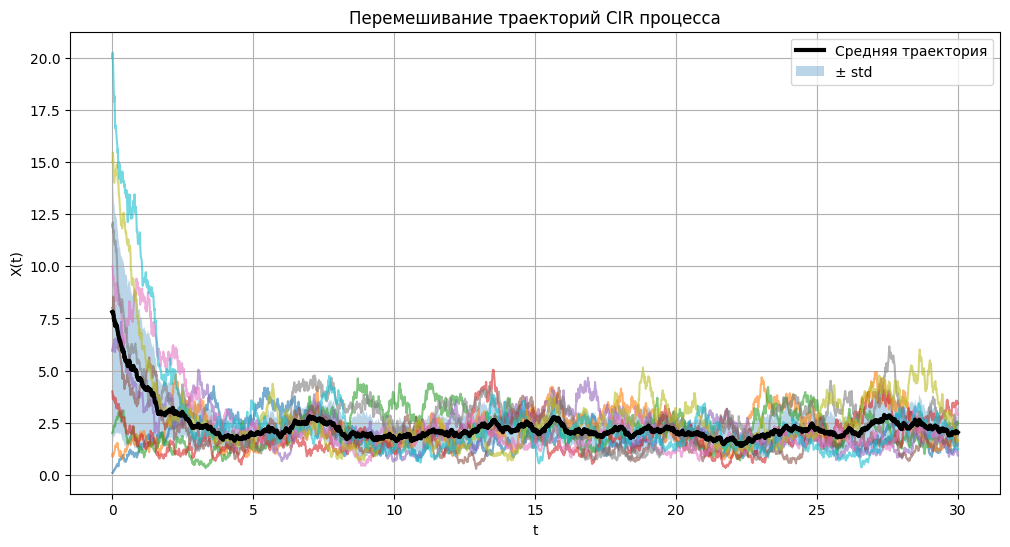

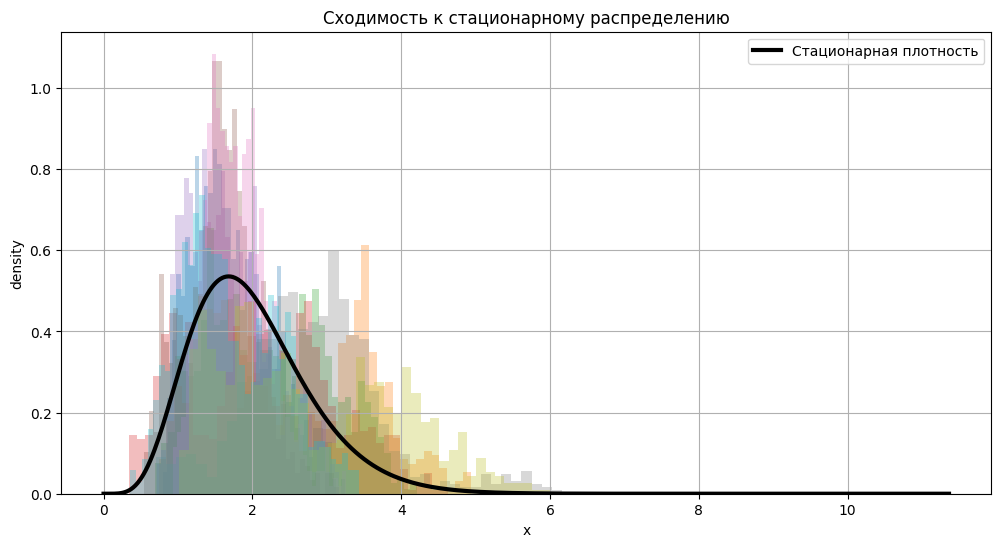

In [23]:
params = [2.0, 1.0, 0.8]

T = 30
Nt = 3000

# начальные состояния
initial_states = np.array([
    0.1,
    1,
    2,
    4,
    6,
    8,
    10,
    12,
    15,
    20])

Ntraj = len(initial_states)

all_trajectories = []
for x0 in initial_states:
    process = CIRprocess(
        params,
        T=T,
        Nt=Nt,
        Nx=1,
        init_state=np.array([x0])    )
    t_data, x_data = process.EulerSolution()
    all_trajectories.append(x_data[:, 0])
all_trajectories = np.array(all_trajectories)


mean_traj = np.mean(all_trajectories, axis=0)
std_traj = np.std(all_trajectories, axis=0)

plt.figure(figsize=(12,6))

for i in range(Ntraj):

    plt.plot(
        t_data,
        all_trajectories[i],
        alpha=0.6    )

# средняя траектория
plt.plot(
    t_data,
    mean_traj,
    'k',
    linewidth=3,
    label='Средняя траектория')

# стандартное отклонение
plt.fill_between(
    t_data,
    mean_traj - std_traj,
    mean_traj + std_traj,
    alpha=0.3,
    label='± std')

plt.xlabel('t')
plt.ylabel('X(t)')
plt.title('Перемешивание траекторий CIR процесса')
plt.grid()
plt.legend()
plt.show()


plt.figure(figsize=(12,6))
for i in range(Ntraj):
    stationary_part = all_trajectories[i, int(0.7*Nt):]
    plt.hist(
        stationary_part,
        bins=40,
        density=True,
        alpha=0.3    )

# теоретическая плотность
x = np.linspace(0, np.quantile(all_trajectories, 0.995), 400)
process_ref = CIRprocess(params, T=T, Nt=Nt, Nx=1)
pi_theory = process_ref.StationaryDistribution(x)

plt.plot(
    x,
    pi_theory,
    'k',
    linewidth=3,
    label='Стационарная плотность')

plt.xlabel('x')
plt.ylabel('density')
plt.title('Сходимость к стационарному распределению')
plt.grid()
plt.legend()
plt.show()

Со временем влияние начального состояния исчезает. Распределения траекторий, стартующих из разных точек, сходятся к одному распределению.
Всн траектории стремятся к одной и той же плотности.

Подтверждается, что процесс является эргодическим, перемешивающим и обладает устойчивым стационарным распределением.

Задача 5. Статистическая верификация качества

1.   Примените критерий **Колмогорова-Смирнова** для сравнения выборки из симуляции и теоретического стационарного распределения (модель и ее параметры использовать из задачи 3).

2.  Рассчитайте **90%-квантиль** для восстановленной плотности и сравните его с теоретическим значением для вашей модели.

3. Приведите иллюстративные графики (теоретические PDF, CDF и их оценки, теоретические значения квартилей и их оценки).

4. Сделайте выводы.


KS statistic = 0.04880694847780151
p-value = 3.3948568236927625e-52
Empirical q90 = 3.2000033349281325
Theoretical q90 = 3.069122320596802


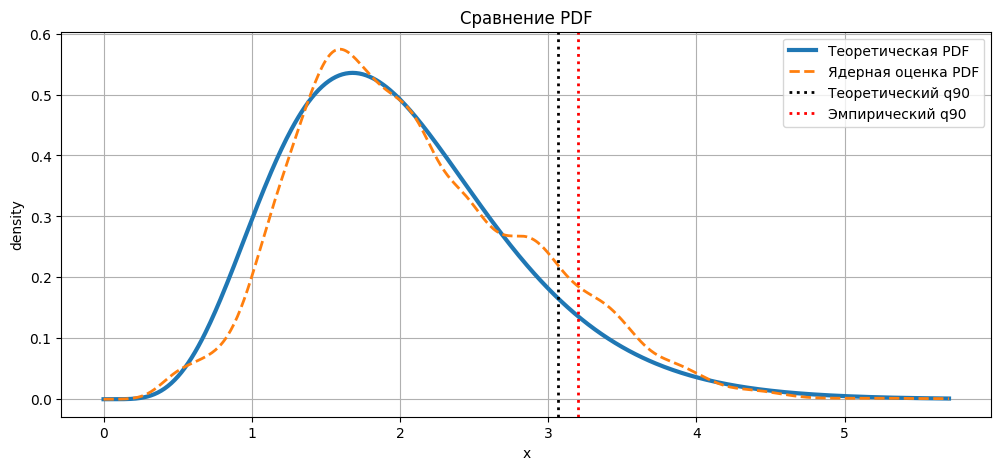

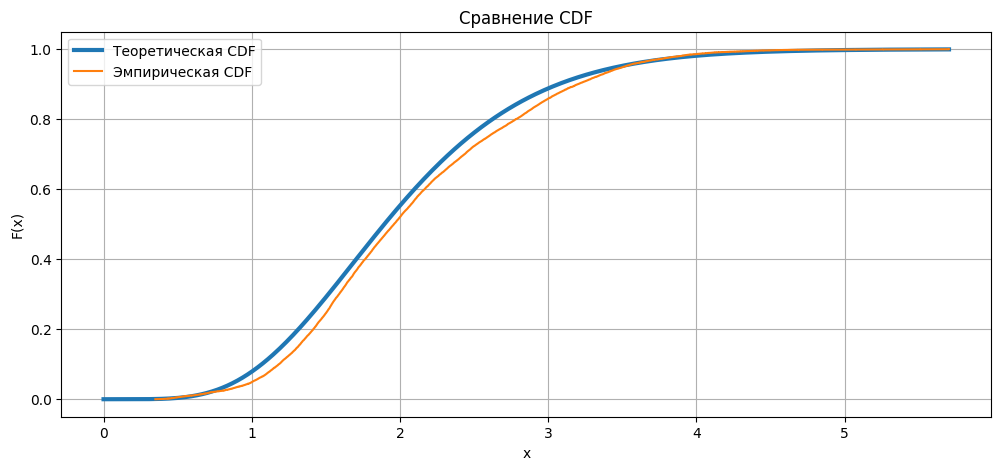

In [35]:
params = [2.0, 1.0, 0.8]

theta1, theta2, theta3 = params

T = 200
Nt = 50000

process = CIRprocess(
    params,
    T=T,
    Nt=Nt,
    Nx=1
)

t_data, x_data = process.EulerSolution()

trajectory = x_data[:, 0]

# стационарная часть
sample = trajectory[int(0.5*Nt):]

k = theta2
theta = theta1 / theta2
sigma = theta3

c = 2 * k / sigma**2
q = 2 * k * theta / sigma**2 - 1

def cir_cdf(x):
    return ncx2.cdf(
        2 * c * x,
        2 * q + 2,
        0
    )

ks_stat, p_value = kstest(
    sample,
    cir_cdf)

print("KS statistic =", ks_stat)
print("p-value =", p_value)

q_empirical = np.quantile(sample, 0.9)
q_theoretical = ncx2.ppf(
    0.9,
    2*q + 2,
    0
) / (2*c)

print("Empirical q90 =", q_empirical)
print("Theoretical q90 =", q_theoretical)

x = np.linspace(
    0,
    np.max(sample),
    500)

pdf_theory = process.StationaryDistribution(x)

pdf_est = StationaryDistributionKernelEstimator(
    x,
    sample)

sample_sorted = np.sort(sample)
ecdf = np.arange(1, len(sample_sorted)+1) / len(sample_sorted)
cdf_theory = cir_cdf(x)

plt.figure(figsize=(12,5))
plt.plot(
    x,
    pdf_theory,
    linewidth=3,
    label='Теоретическая PDF')

plt.plot(
    x,
    pdf_est,
    '--',
    linewidth=2,
    label='Ядерная оценка PDF')

plt.axvline(
    q_theoretical,
    color='black',
    linestyle=':',
    linewidth=2,
    label='Теоретический q90')

plt.axvline(
    q_empirical,
    color='red',
    linestyle=':',
    linewidth=2,
    label='Эмпирический q90')

plt.xlabel('x')
plt.ylabel('density')
plt.title('Сравнение PDF')
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(
    x,
    cdf_theory,
    linewidth=3,
    label='Теоретическая CDF')
plt.step(
    sample_sorted,
    ecdf,
    where='post',
    label='Эмпирическая CDF')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Сравнение CDF')
plt.grid()
plt.legend()

plt.show()

Эмпирическое распределение хорошо согласуется с теоретическим. Значение ститистики Колмогорова-Смирнова указывает на то же.
р-значение приводит к отклонению нулевой гипотезы о полном совпадении распределений, но это можно объяснить большим объёмом выборки
Полученная плотность согласуется с теоретической.  Эмпирическая функция распредление практически совпадает с теоретической.
